### Part 2 of the thesis

In [1]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import training_lib as tl
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
from helperfunctions.detection import DET_OVERVIEW_COLS
from torch import nn
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple
import numpy as np
import os
from glob import glob
%matplotlib widget

pd.set_option("display.max_columns", None)

In [2]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)

{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [3]:
print(f"test start:{cfg_part2.test_start_time}\n"
      f"test end:  {cfg_part2.test_end_time}")

test start:2020-05-01 04:10:00
test end:  2022-12-31 23:50:00


In [4]:
_, _, test_loader = hfn.build_dataloaders(
    train_csv_dir=ic.PATH_PC_FILTERING,
    val_csv_dir=ic.PATH_IMPUTED,
    test_csv_dir=ic.PATH_IMPUTED,
    cfg=cfg_part2
)

### Load Autoencoder

In [5]:
best = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
ae, _, _, _, _ = best[0]

ae = ae.to(cfg_part2.device).eval()

loss_fn = nn.MSELoss(reduction="none")


C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425



### Load threshold 

In [6]:
theta = p2.load_threshold_table()

   WT_ID    k        mu     sigma  threshold   tp   fn     fp  precision  \
0      1  1.0  0.013096  0.029094    0.04219  7.0  1.0  236.0   0.028807   

   recall        f1  FAR_per_day  latency_mean  
0   0.875  0.055777     1.594595    111.714286  


In [7]:
test_eval_df = tl.eval_model(
    model=ae,
    data_loader=test_loader,
    device=cfg_part2.device,
    loss_fn = loss_fn
)
display(test_eval_df.head())

os.makedirs(ic.PATH_PART2_EVAL_TEST, exist_ok=True)
test_eval_df.to_csv(ic.PATH_PART2_EVAL_TEST / "eval_test_set.csv", index=False)


,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
842250,1588306200000000001,2020-05-01 04:10:00,1,0.021798,0.008148,0.094487,0.020666,0.021166,0.002876,0.011175,0.003134,0.002139,0.083261,0.000055,0.000006,0.006936,0.027010,2.388245e-01,0.002420,0.000163,0.001425,0.001798,1.648817e-06,1.111275e-02,0.002902,0.002989,0.003100,0.018406,0.000058,0.000525,0.002179,0.002669,0.002781,0.001968,0.000169,0.004524,0.000044,0.000239,0.012340,0.000073,0.000367,0.236192
982625,1588306200000000002,2020-05-01 04:10:00,2,0.026611,0.005555,0.147881,0.003152,0.005707,0.000037,0.000812,0.001665,0.000005,0.008374,0.000661,0.001424,0.000864,0.001743,2.390153e-01,0.006600,0.005054,0.180388,0.000170,2.252205e-03,1.640601e-02,0.002016,0.003590,0.003878,0.027006,0.000309,0.002825,0.000692,0.000909,0.000992,0.014479,0.004077,0.037727,0.014320,0.001727,0.014470,0.003942,0.013449,0.237053
1123000,1588306200000000004,2020-05-01 04:10:00,4,0.002452,0.000042,0.000007,0.002139,0.001538,0.000092,0.000897,0.000340,0.000293,0.026001,0.000186,0.000001,0.001525,0.000315,9.567735e-05,0.038999,0.002810,0.001857,0.000648,1.571099e-09,1.076651e-07,0.000094,0.000615,0.000009,0.000876,0.000004,0.001630,0.000468,0.000294,0.000284,0.000529,0.000318,0.003309,0.000072,0.000651,0.005969,0.000130,0.000011,0.000130
1263375,1588306200000000005,2020-05-01 04:10:00,5,0.013120,0.005832,0.035099,0.013446,0.022986,0.000044,0.008692,0.004631,0.000002,0.000229,0.014190,0.004403,0.012072,0.003371,4.101939e-05,0.005850,0.001402,0.003673,0.000112,9.969746e-04,5.928122e-05,0.000172,0.000108,0.000001,0.000500,0.249002,0.008641,0.000214,0.000377,0.000418,0.002332,0.004244,0.015442,0.001185,0.018634,0.051762,0.007190,0.001146,0.000083
1403750,1588306200000000006,2020-05-01 04:10:00,6,0.013144,0.000221,0.043485,0.000567,0.001858,0.005117,0.000530,0.010470,0.001455,0.000081,0.000861,0.000829,0.000894,0.003858,2.060028e-08,0.005266,0.004495,0.000031,0.000075,1.441789e-03,1.015547e-02,0.047146,0.044287,0.046548,0.017712,0.236755,0.001082,0.001290,0.001459,0.000232,0.000188,0.000374,0.001174,0.001621,0.000152,0.001344,0.002955,0.003236,0.000237


### We need to drop the Imputations from test_eval_df

In [8]:
test_eval_clean = p2.drop_imputations(test_eval_df)

In [9]:
detections_df = test_eval_clean[test_eval_clean[ic.MEAN_LOSS_PER_SAMPLE] >= theta]
detections_df = detections_df.sort_values(by=ic.MEAN_LOSS_PER_SAMPLE, ascending=False).reset_index(drop=True)

In [12]:
display(detections_df.head())
display(len(detections_df))

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1641412800000000012,2022-01-05 20:00:00,12,8.343366,185.189804,0.161642,0.084029,0.162505,0.079211,0.356811,0.116971,0.030900,0.299494,0.194252,0.159235,0.179299,0.442263,0.119040,0.354230,0.127760,0.339420,0.244801,5.577356e-03,0.337084,0.301709,0.194832,0.145359,0.646463,0.265135,0.453654,0.653850,0.571475,0.650402,0.431948,0.001236,0.565393,0.660837,0.163096,0.084972,120.361855,1.656347,0.255011
1,1638304800000000015,2021-11-30 20:40:00,15,7.308167,221.789429,0.082104,0.026219,0.063605,0.034467,0.003375,0.288460,0.009168,0.128606,0.054019,0.098470,0.000431,0.778771,0.000592,0.189329,0.063289,0.036329,0.106394,2.100649e-02,0.187834,0.063840,0.100353,0.000311,0.680240,0.014636,0.209595,0.423571,0.026448,0.022054,0.199845,0.003873,0.000185,0.000030,0.156328,0.012637,50.305603,1.514961,0.013934
2,1607461200000000007,2020-12-08 21:00:00,7,6.686425,160.447952,0.044653,0.153851,0.149239,0.127547,0.174829,0.076791,0.001088,0.026391,0.214277,0.059490,0.084280,0.233611,0.004736,0.102608,0.000041,0.071468,0.160990,5.603883e-04,0.150213,0.196372,0.210059,0.000237,0.156342,0.045837,0.260354,0.451990,0.041907,0.071026,0.218922,0.000388,0.000864,0.006635,0.188975,0.017256,88.545135,1.338055,0.049147
3,1637131800000000006,2021-11-17 06:50:00,6,2.243517,40.572876,0.155494,0.000003,0.001098,0.002843,0.003309,0.006369,0.116243,0.010067,0.002753,0.000045,0.002712,0.113061,0.001279,0.005069,0.040431,0.113823,0.000979,2.122084e-08,0.072420,0.016454,0.003565,0.000565,0.021061,0.000935,0.001202,0.185968,0.057509,0.084316,0.032460,0.073693,0.005464,0.013264,0.001733,0.003281,40.832470,2.697380,0.001447
4,1607464800000000007,2020-12-08 22:00:00,7,2.098754,46.369118,0.052177,0.043424,0.268129,0.009930,0.002586,0.004857,0.011050,0.140253,0.006403,0.001007,0.004696,0.226469,0.000048,0.068855,0.051567,0.118243,0.024825,4.942935e-04,0.116744,0.000144,0.004017,0.004575,0.000339,0.001985,0.050567,0.208715,0.091525,0.120024,0.019027,0.025336,0.005715,0.007731,0.031137,0.002448,31.156683,0.501737,0.000077


68809

In [11]:
selected_detections = p2.select_top_detections_with_gap(
    det_df=detections_df,
    top_n=None,
    gap_days=1,
    save_filename="part2_dets_gdays_1.csv"
)

In [13]:
display(selected_detections)

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1641412800000000012,2022-01-05 20:00:00,12,8.343366,185.189804,0.161642,0.084029,1.625053e-01,0.079211,0.356811,0.116971,0.030900,0.299494,0.194252,0.159235,0.179299,0.442263,0.119040,0.354230,0.127760,0.339420,0.244801,5.577356e-03,0.337084,0.301709,0.194832,0.145359,0.646463,0.265135,0.453654,0.653850,0.571475,0.650402,0.431948,0.001236,0.565393,0.660837,0.163096,8.497208e-02,120.361855,1.656347,0.255011
1,1638304800000000015,2021-11-30 20:40:00,15,7.308167,221.789429,0.082104,0.026219,6.360460e-02,0.034467,0.003375,0.288460,0.009168,0.128606,0.054019,0.098470,0.000431,0.778771,0.000592,0.189329,0.063289,0.036329,0.106394,2.100649e-02,0.187834,0.063840,0.100353,0.000311,0.680240,0.014636,0.209595,0.423571,0.026448,0.022054,0.199845,0.003873,0.000185,0.000030,0.156328,1.263669e-02,50.305603,1.514961,0.013934
2,1607461200000000007,2020-12-08 21:00:00,7,6.686425,160.447952,0.044653,0.153851,1.492391e-01,0.127547,0.174829,0.076791,0.001088,0.026391,0.214277,0.059490,0.084280,0.233611,0.004736,0.102608,0.000041,0.071468,0.160990,5.603883e-04,0.150213,0.196372,0.210059,0.000237,0.156342,0.045837,0.260354,0.451990,0.041907,0.071026,0.218922,0.000388,0.000864,0.006635,0.188975,1.725636e-02,88.545135,1.338055,0.049147
3,1637131800000000006,2021-11-17 06:50:00,6,2.243517,40.572876,0.155494,0.000003,1.098039e-03,0.002843,0.003309,0.006369,0.116243,0.010067,0.002753,0.000045,0.002712,0.113061,0.001279,0.005069,0.040431,0.113823,0.000979,2.122084e-08,0.072420,0.016454,0.003565,0.000565,0.021061,0.000935,0.001202,0.185968,0.057509,0.084316,0.032460,0.073693,0.005464,0.013264,0.001733,3.281211e-03,40.832470,2.697380,0.001447
4,1634922600000000007,2021-10-22 17:10:00,7,2.033795,0.183905,0.197341,0.481804,9.396648e-01,0.270806,2.538486,0.277935,0.063816,1.346212,1.970649,0.266793,1.723406,1.251133,1.534647,1.315558,0.375721,2.397292,3.838344,1.076914e-01,0.945492,0.913471,0.915312,0.054548,27.229046,0.443886,2.916031,3.951937,1.560990,2.449968,0.219454,0.052992,2.129529,2.982091,0.363277,4.962097e+00,2.100800,1.624950,0.387149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4246,1617589800000000004,2021-04-05 02:30:00,4,0.042208,0.002412,0.000017,0.137855,3.717969e-02,0.122224,0.002799,0.000393,0.116328,0.023762,0.092779,0.154333,0.080475,0.000031,0.000037,0.000003,0.211971,0.000002,0.109817,3.537389e-04,0.000054,0.000604,0.005160,0.000927,0.000390,0.000027,0.100491,0.071569,0.073947,0.074507,0.000918,0.043558,0.004149,0.023565,0.041169,1.635947e-03,0.066539,0.001831,0.000074
4247,1645484400000000007,2022-02-21 23:00:00,7,0.042206,0.008672,0.005798,0.032461,4.771565e-02,0.163364,0.001536,0.000022,0.163018,0.073981,0.000616,0.015064,0.006892,0.

### Power Curve 

In [13]:
pre_step5 = PreprocessingStep5()
df_pc = pre_step5._prepare_power_curve()
df_pc.head()

,power_norm
0.00,0.0
0.01,0.0
0.02,0.0
0.03,0.0
0.04,0.0


In [14]:
test_start = cfg_part2.test_start_time
test_end = cfg_part2.test_end_time

wind_col = "Wind speed (m/s)"
power_col = "Power (kW)"

imputed_files = sorted(Path(ic.PATH_IMPUTED).glob("*.csv"))

wt_farm : list[pd.DataFrame] = []

for file in imputed_files:
    df_wt = pd.read_csv(file, parse_dates=[ic.TS_COL])
    df_wt[ic.TS_COL]= pd.to_datetime(df_wt[ic.TS_COL])
    df_wt = df_wt.set_index(ic.TS_COL).sort_index()
    
    df_wt_test = df_wt.loc[test_start:test_end].copy()
    
    df_wt_test[ic.TS_COL] = df_wt_test.index
    wt_farm.append(df_wt_test.reset_index(drop=True))
    
wt_farm_df = pd.concat(wt_farm, axis=0)
wt_farm_df = wt_farm_df.sort_values([ic.WT_ID, ic.TS_COL])
wt_farm_df.head()

wt_farm_pc_df = wt_farm_df[[c for c in [ic.WT_ID, ic.TS_COL, wind_col, power_col] if c in wt_farm_df.columns]].copy()

wt_farm_path = ic.PATH_PART2_WT_FARM
os.makedirs(wt_farm_path, exist_ok=True)

wt_farm_pc_df.to_csv(wt_farm_path /  "wt_farm_pc_df.csv", index=False)

In [15]:
fps = glob(os.path.join(ic.PATH_PART2_DETECTIONS, "part2_dets_gdays_1.csv"))
print(fps)
fp = fps[0]
df_detections = pd.read_csv(fp, parse_dates=[ic.TS_COL])
df_detections[ic.TS_COL] = pd.to_datetime(df_detections[ic.TS_COL])


df_det_keys = df_detections[[ic.WT_ID, ic.TS_COL]].copy()

df_det_points = df_det_keys.merge(
    wt_farm_pc_df[[ic.WT_ID,ic.TS_COL, wind_col, power_col]],
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)

df_det_points.head()

['C:\\Users\\admin\\Uni\\Abschlussarbeit\\github\\BSc-Thesis-Multi-Wind-Turbine-AD\\src\\Penmanshiel\\processed_data\\signal_imputation\\part2\\detections\\part2_dets_gdays_1.csv']


,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,12,2022-01-05 20:00:00,6.341438,230.972735
1,15,2021-11-30 20:40:00,5.614177,182.038048
2,7,2020-12-08 21:00:00,2.360587,-1.277555
3,6,2021-11-17 06:50:00,6.780597,337.755948
4,7,2021-10-22 17:10:00,1.064987,-0.909158


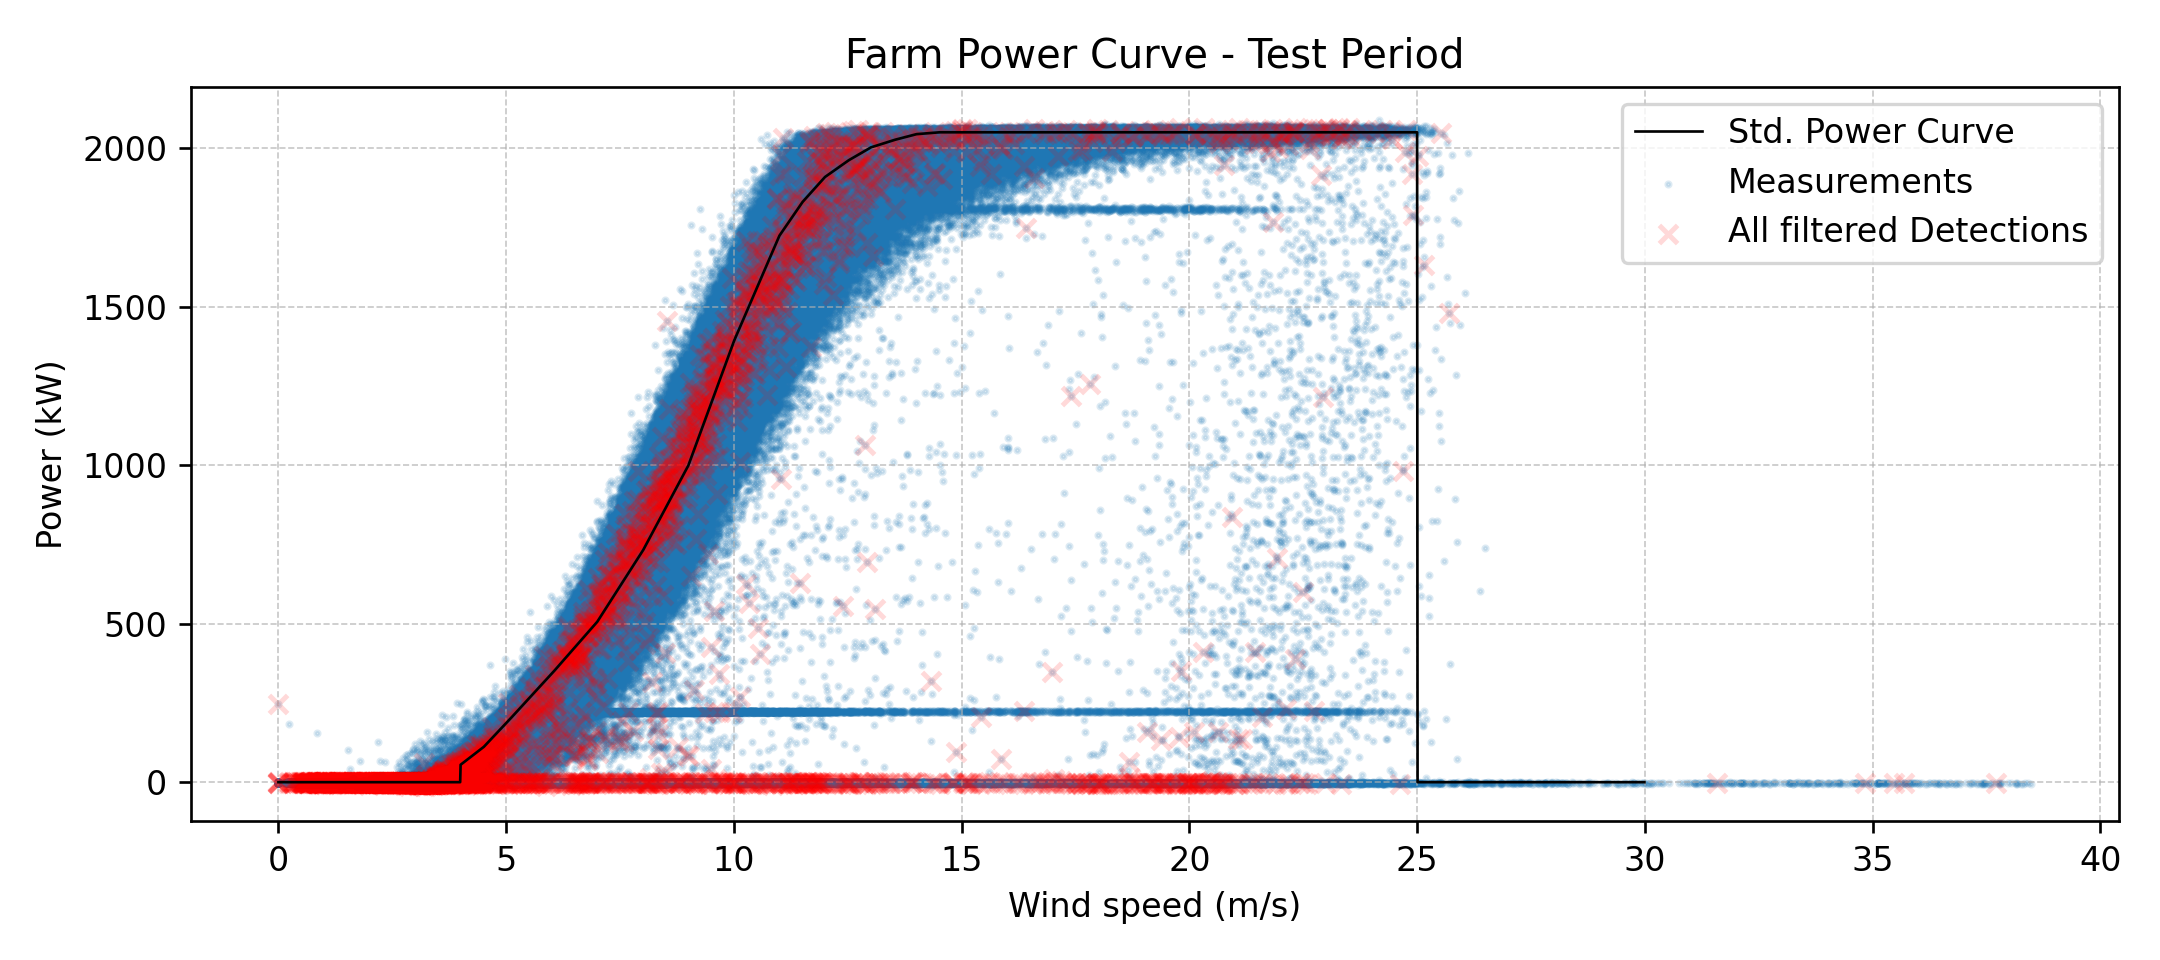

In [16]:
pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_pc_df),
                    df_detections=df_det_points,
                    detections_label="All filtered Detections"
                    )

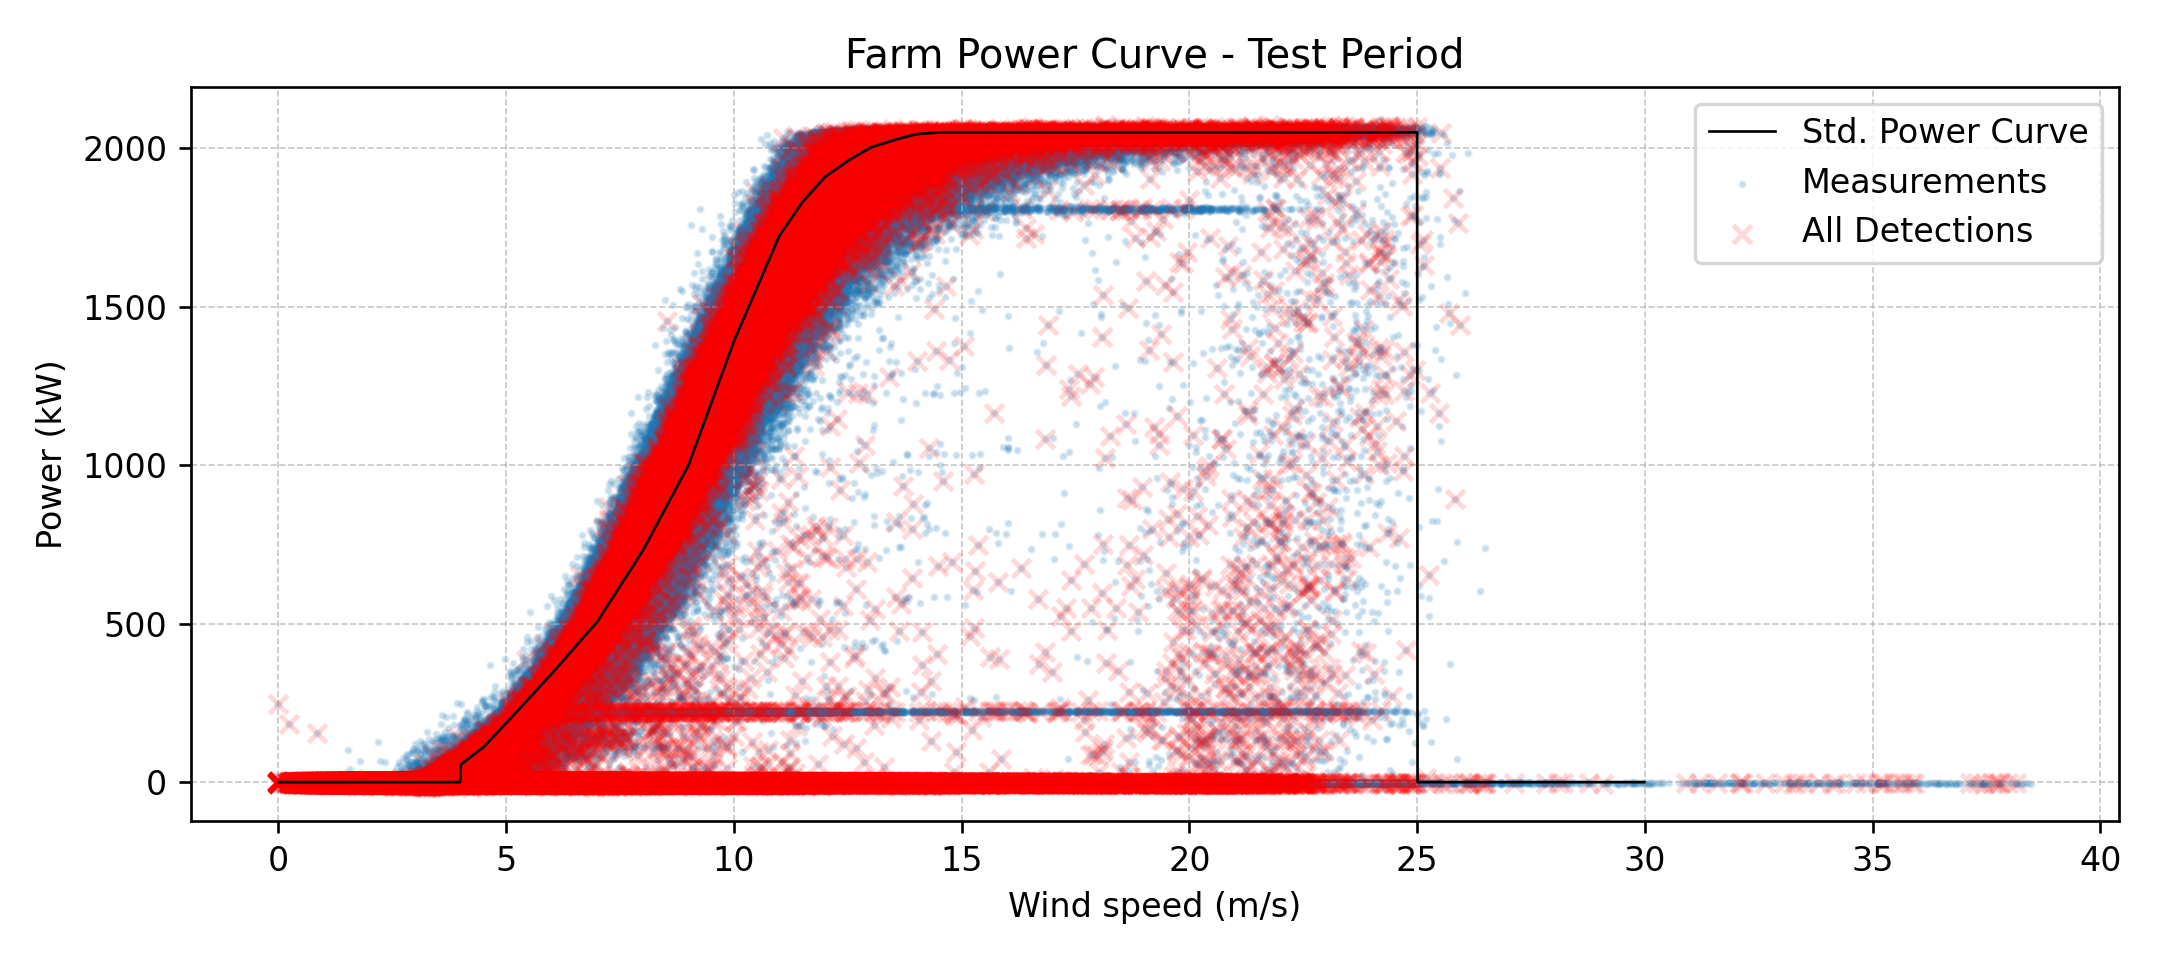

In [17]:
sel_det_no_gaps = p2.select_top_detections_with_gap(
    det_df=detections_df,
    top_n=None,
    gap_days=0,
    save_filename="part2_dets_no_gaps.csv"
)

df_det_keys_ng = sel_det_no_gaps[[ic.WT_ID, ic.TS_COL]].copy()

df_det_points_ng = df_det_keys_ng.merge(
    wt_farm_pc_df[[ic.WT_ID,ic.TS_COL, wind_col, power_col]],
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)

df_det_points_ng.head()

df_det_points_ng.to_csv(ic.PATH_PART2_DETECTIONS/ "det_points_no_gap.csv", index=False)

pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_pc_df),
                    df_detections=df_det_points_ng,
                    detections_label="All Detections"
                    )



In [18]:
print(f"total samples (no imputations): {len(p2.drop_imputations( wt_farm_pc_df))}")
print(f"Total Number of detections: {len(df_det_points_ng)}")
print(f"Share of detections: {len(df_det_points_ng) / len(p2.drop_imputations( wt_farm_pc_df))}")

total samples (no imputations): 1791804
Total Number of detections: 68809
Share of detections: 0.038402079691752
